In [1]:
from utils import *
from genData import *
import time 
np.random.seed(111)
torch.manual_seed(111)


25-07-20 18:24:41.041 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


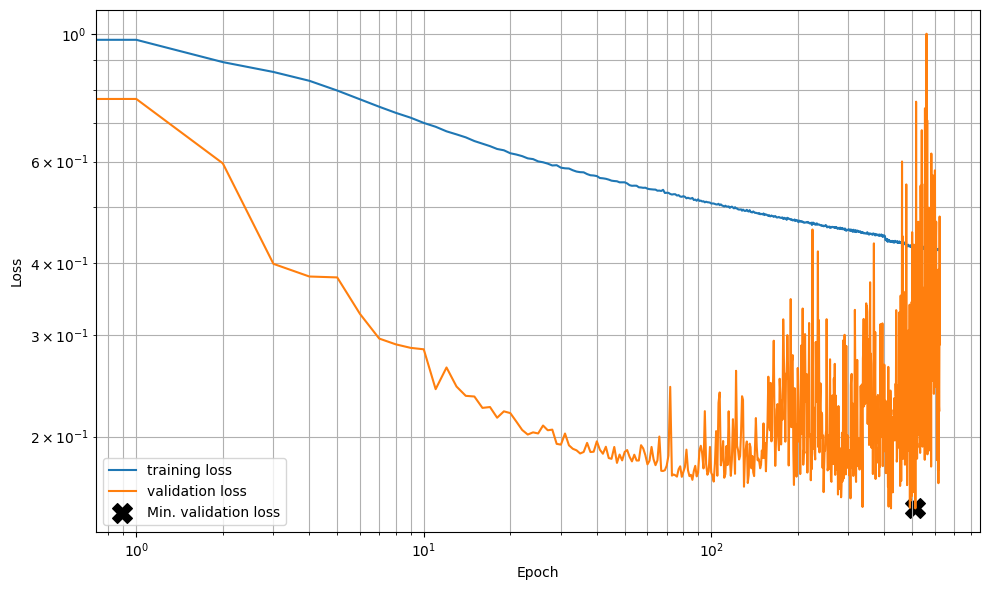

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 500
version = f'H1L1_a1.0b1.0_{f0}Hz_D21-21_T10_Tsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'
data = np.load('/scratch/kriles_root/kriles0/damoncht/unet_f/trained_model/{}Hz/losses_{}.npy'.format(f0, version), allow_pickle=True)
train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

train_losses = data.item()['train_losses']
val_losses = data.item()['val_losses']
top_val_loss = data.item()['top_val_loss']

train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

plt.figure(figsize=(10, 6))
plt.plot(train_losses[5:]/train_losses[5:].max(), label='training loss')
plt.plot(val_losses/val_losses.max(), label='validation loss')
idx = np.argmin(val_losses-top_val_loss)
plt.scatter(idx, top_val_loss/val_losses.max(), color='k', marker='X', label='Min. validation loss', s=200)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))
plt.show()


dict_keys([8, 18, 19, 20, 35.6])


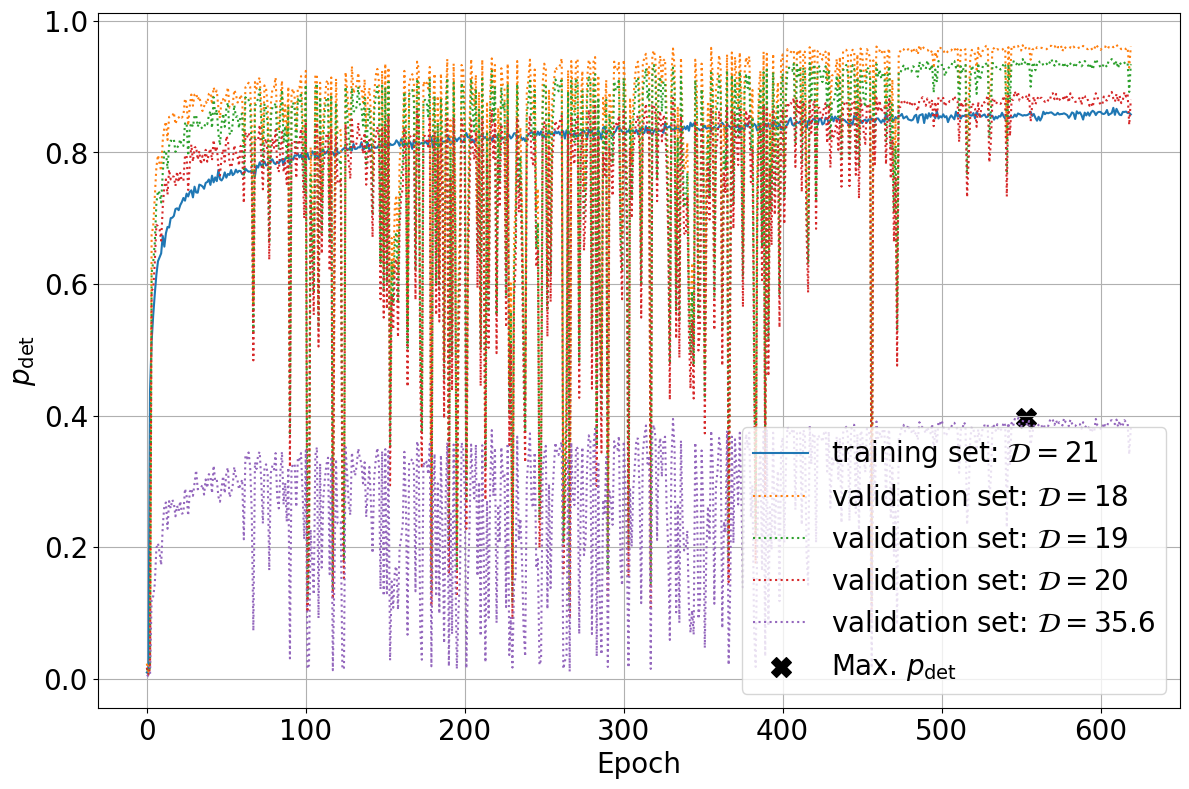

In [8]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
fig, axs = plt.subplots(1, 1, figsize=(12, 8))


train_pdet = data.item()['train_pdet']
val_pdet = data.item()['val_pdet']

method = 'mean_sq'
print(val_pdet[method].keys())

for i, key in enumerate(train_pdet[method].keys()):
    axs.plot(train_pdet[method][key][5:], label='training set: '+r'$\mathcal{D}=$'+str(key), color=colors[i])

for i, key in enumerate(val_pdet[method].keys()):
    if key ==8:
        continue
    axs.plot(val_pdet[method][key][5:], ls='dotted', label='validation set: '+r'$\mathcal{D}=$'+str(key), color=colors[i])
    
idx = np.where(val_pdet[method][35.6]==max(val_pdet[method][35.6]))[0]
plt.scatter(idx, np.ones(idx.size)*max(val_pdet[method][35.6]), color='k', marker='X', label='Max. '+r'$p_\mathrm{det}$', s=200)

#axs.grid(True, which='major', axis='x', linestyle='-', alpha=1)  # Major vertical grid
#axs.grid(True, which='minor', axis='x', linestyle='-', alpha=1)  # Minor vertical grid at 

# We change the fontsize of minor ticks label 
axs.tick_params(axis='both', which='major', labelsize=20)
axs.tick_params(axis='both', which='minor', labelsize=20)


# Set x-axis limits and ticks
#axs.set_xlim(0, n_weeks)

# Set title
#plt.suptitle('O4ab H1/L1 observing segments', fontsize=15)

# Adjust layout


plt.legend()
plt.xlabel('Epoch', fontsize=20)
plt.ylabel(r'$p_\mathrm{det}$', fontsize=20)
plt.legend(fontsize=20)
plt.grid()
plt.tight_layout()

plt.savefig('./plots/pdet_train_pdet_500Hz.pdf'.format(version))
#plt.savefig('./plots/pdet_train_pdet.png'.format(version))

#plt.yscale('log')

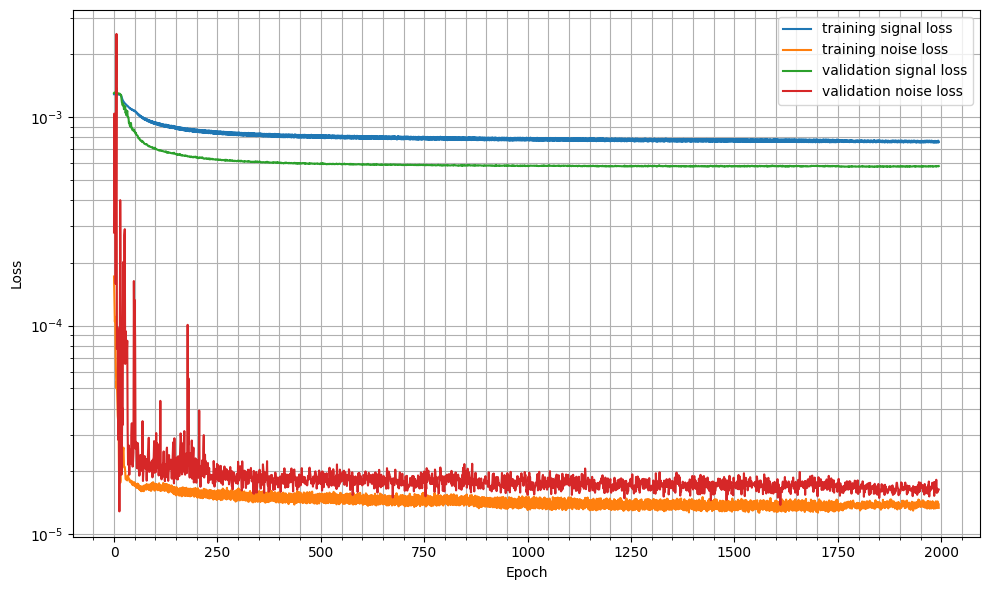

In [4]:
a = data.item()['train_mse_signal']
b = data.item()['train_mse_noise']

plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='training signal loss')
plt.plot(b[5:], label='training noise loss')

# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.minorticks_on()
# plt.grid(which='both')
# plt.tight_layout()
# plt.show()

a = data.item()['val_mse_signal']
b = data.item()['val_mse_noise']

#plt.figure(figsize=(10, 6))
plt.plot(a[5:], label='validation signal loss')
plt.plot(b[5:], label='validation noise loss')

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
#plt.title('Loss Curve')
#plt.ylim(0, 0.55)
plt.minorticks_on()
plt.grid(which='both')
plt.tight_layout()
#plt.savefig('./plots/loss_{}.pdf'.format(version))
#plt.savefig('./plots/loss_{}.png'.format(version))

plt.show()